In [1]:
import pandas as pd
import os

folder = "."

dfs = []

for file in os.listdir(folder):
    
    if file.endswith(".csv"):
        
        skill = file.replace(".csv","")
        
        df = pd.read_csv(os.path.join(folder,file))
        
        df = df.rename(columns={
            df.columns[0]:"date",
            df.columns[1]:skill
        })
        
        dfs.append(df)

In [5]:
from functools import reduce

trends = reduce(
    lambda left,right: pd.merge(left,right,on="date",how="outer"),
    dfs
)

trends.head()

,date,Big Data,C++,Cloud Computing,Communication,Computer Vision,Data Visualization,Deep Learning,Generative AI,JAVA,...,NLP,Problem Solving,Project Management,Python,Pytorch,R,Scikit-Learn,SQL,Statistics,TensorFlow
0,2023-03-01,31,95,23,47,18,52,28,13,82,...,79,70,55,100,94,83,99,100,39,100
1,2023-04-01,29,89,21,45,18,53,25,16,77,...,72,67,72,94,95,88,100,92,39,89
2,2023-05-01,26,71,21,43,16,46,22,27,70,...,67,57,49,86,80,78,73,87,35,70
3,2023-06-01,22,65,18,36,17,41,21,38,69,...,68,40,49,84,76,74,63,92,23,72
4,2023-07-01,22,65,19,34,16,42,21,30,69,...,65,36,49,81,76,72,62,86,24,70


In [7]:
trends.to_csv("google_trends_cleaned.csv", index=False)

In [9]:
trends["date"] = pd.to_datetime(trends["date"])
trends = trends.sort_values("date")
trends.set_index("date", inplace=True)

In [11]:
trends.isna().sum()

Big Data              0
C++                   0
Cloud Computing       0
Communication         0
Computer Vision       0
Data Visualization    0
Deep Learning         0
Generative AI         0
JAVA                  0
Machine Learning      0
MLOps                 0
NLP                   0
Problem Solving       0
Project Management    0
Python                0
Pytorch               0
R                     0
Scikit-Learn          0
SQL                   0
Statistics            0
TensorFlow            0
dtype: int64

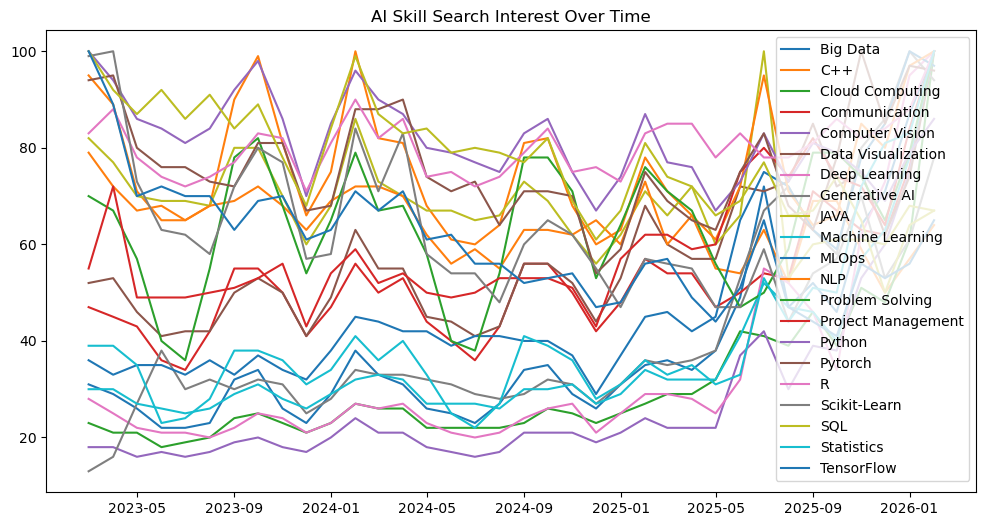

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for skill in trends.columns:
    plt.plot(trends.index, trends[skill], label=skill)

plt.legend()
plt.title("AI Skill Search Interest Over Time")
plt.show()

In [15]:
avg = trends.mean().sort_values(ascending=False)

avg

Python                81.500000
R                     80.388889
SQL                   77.500000
Pytorch               76.472222
C++                   70.583333
NLP                   69.694444
JAVA                  68.722222
Problem Solving       64.500000
Scikit-Learn          63.277778
TensorFlow            60.527778
Project Management    59.805556
Data Visualization    57.000000
Communication         52.138889
MLOps                 48.083333
Generative AI         41.388889
Statistics            40.722222
Big Data              38.500000
Machine Learning      36.444444
Deep Learning         33.333333
Cloud Computing       30.861111
Computer Vision       27.694444
dtype: float64

Text(0.5, 1.0, 'Top AI Skills by Search Interest')

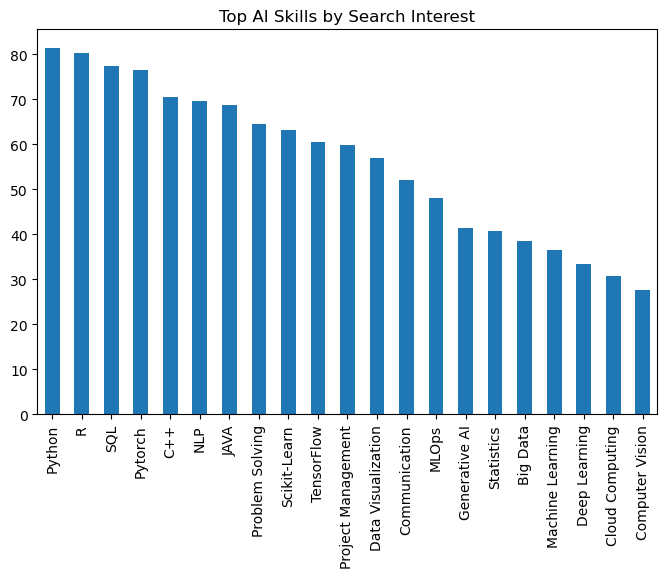

In [17]:
avg.plot(kind="bar",figsize=(8,5))
plt.title("Top AI Skills by Search Interest")

In [19]:
growth = trends.iloc[-1] - trends.iloc[0]

growth.sort_values(ascending=False)

Computer Vision       82
Generative AI         81
Cloud Computing       77
Deep Learning         72
Machine Learning      70
Big Data              69
MLOps                 61
Statistics            61
Communication         53
Data Visualization    48
Project Management    45
Problem Solving       30
NLP                   21
R                     17
Pytorch                2
Python               -14
JAVA                 -15
Scikit-Learn         -21
C++                  -31
SQL                  -33
TensorFlow           -35
dtype: int64

Text(0.5, 1.0, 'Skill Demand Correlation')

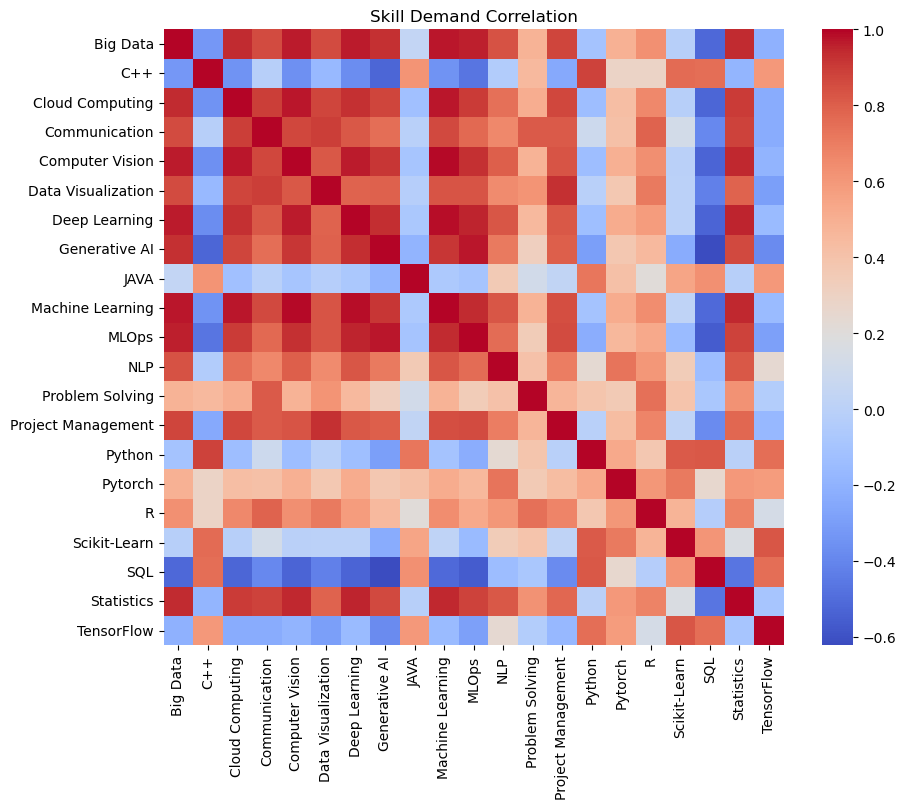

In [23]:
import seaborn as sns

corr = trends.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,cmap="coolwarm")
plt.title("Skill Demand Correlation")

In [25]:
skill_name = "Python" 

ts = trends[[skill_name]].reset_index()
ts.columns = ["ds", "y"]

ts

,ds,y
0,2023-03-01,100
1,2023-04-01,94
2,2023-05-01,86
3,2023-06-01,84
4,2023-07-01,81
5,2023-08-01,84
6,2023-09-01,92
7,2023-10-01,98
8,2023-11-01,86
9,2023-12-01,70


C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
16:03:11 - cmdstanpy - INFO - Chain [1] start processing
16:03:12 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


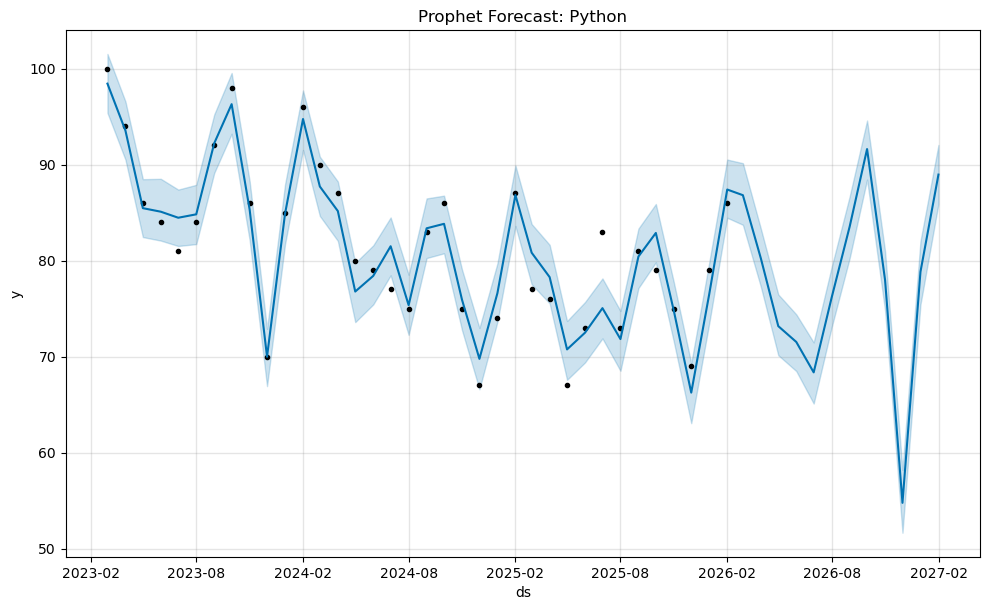

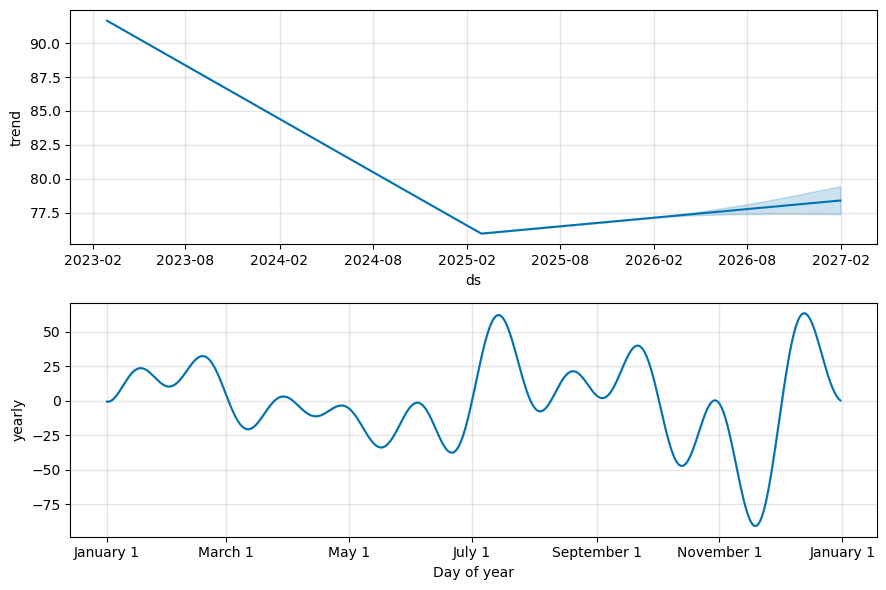

In [27]:
from prophet import Prophet

model = Prophet()
model.fit(ts)

future = model.make_future_dataframe(periods=12, freq="M")
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title(f"Prophet Forecast: {skill_name}")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [29]:
skill_name = "Generative AI" 

ts = trends[[skill_name]].reset_index()
ts.columns = ["ds", "y"]

ts

,ds,y
0,2023-03-01,13
1,2023-04-01,16
2,2023-05-01,27
3,2023-06-01,38
4,2023-07-01,30
5,2023-08-01,32
6,2023-09-01,30
7,2023-10-01,32
8,2023-11-01,31
9,2023-12-01,25


16:03:16 - cmdstanpy - INFO - Chain [1] start processing
16:03:16 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


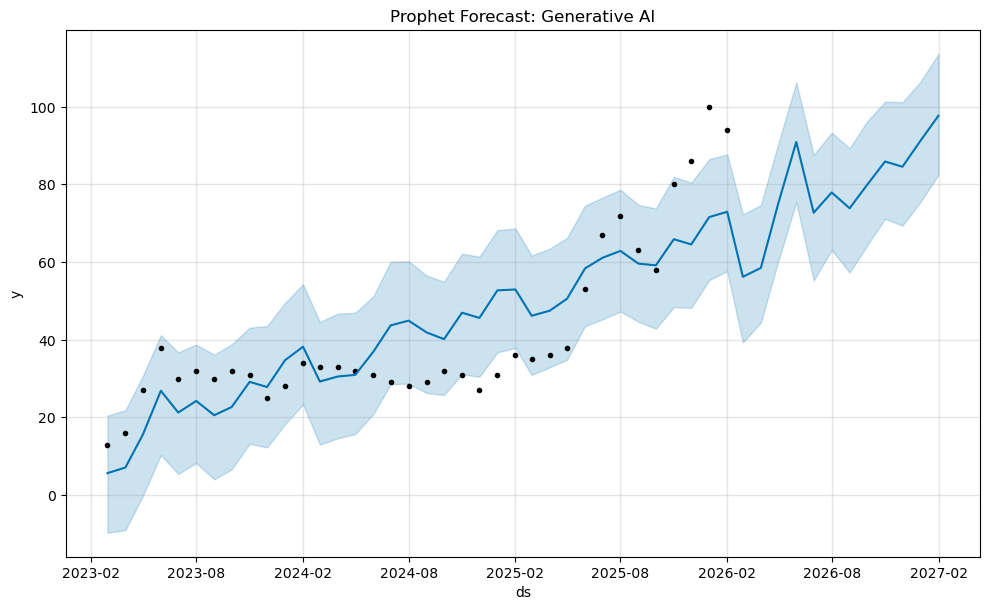

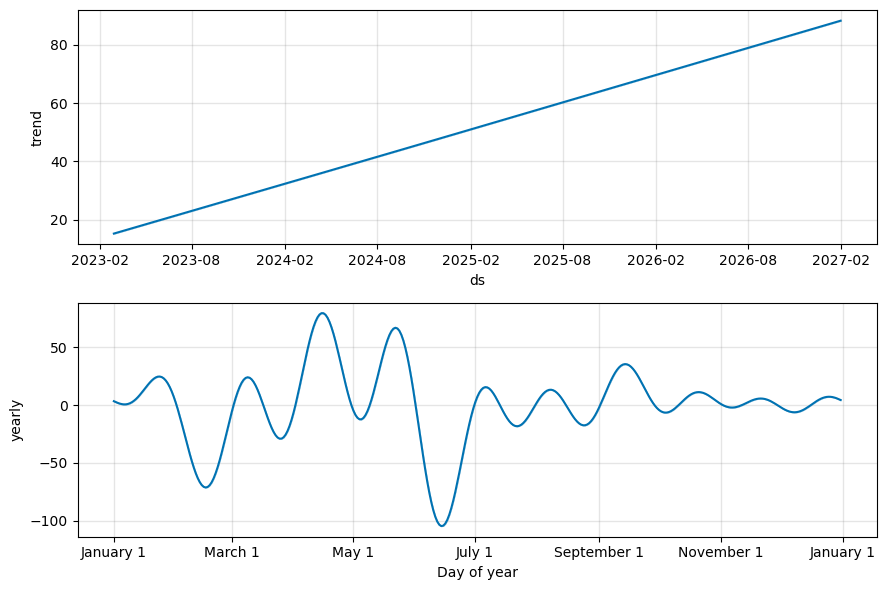

In [31]:
from prophet import Prophet

model = Prophet()
model.fit(ts)

future = model.make_future_dataframe(periods=12, freq="M")  # 预测未来12个月
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title(f"Prophet Forecast: {skill_name}")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [33]:
skill_name = "Machine Learning" 

ts = trends[[skill_name]].reset_index()
ts.columns = ["ds", "y"]

ts

,ds,y
0,2023-03-01,30
1,2023-04-01,30
2,2023-05-01,27
3,2023-06-01,26
4,2023-07-01,25
5,2023-08-01,26
6,2023-09-01,29
7,2023-10-01,31
8,2023-11-01,28
9,2023-12-01,26


16:03:20 - cmdstanpy - INFO - Chain [1] start processing
16:03:21 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


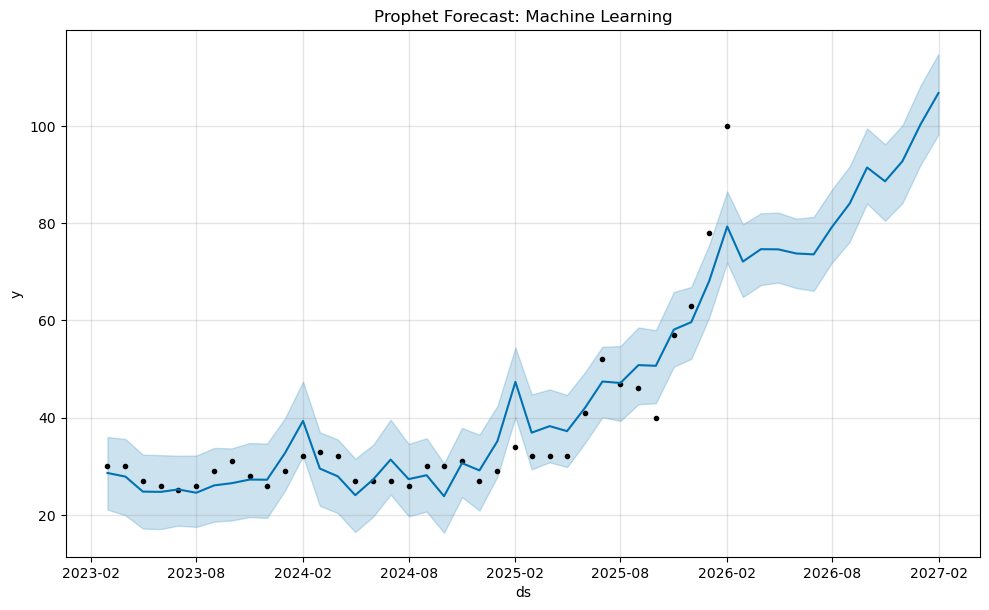

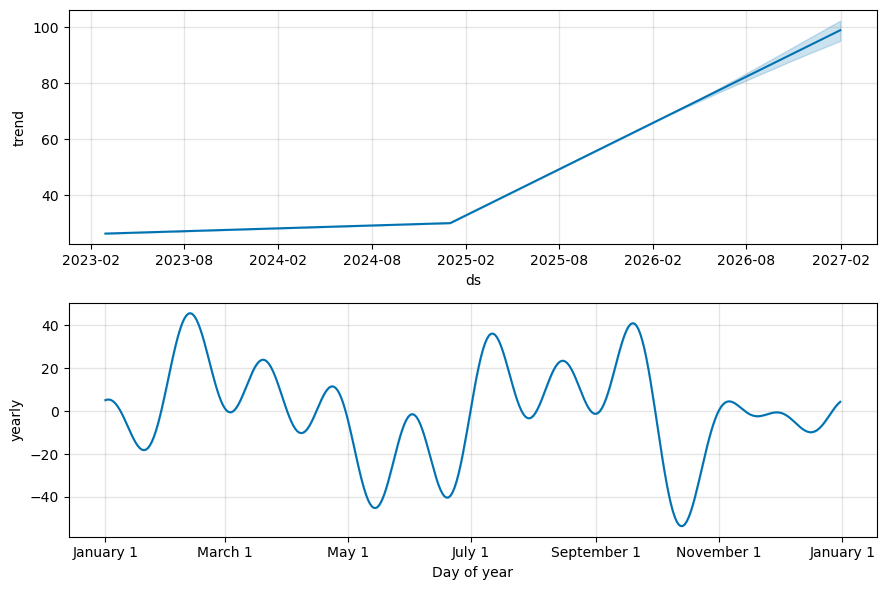

In [35]:
from prophet import Prophet

model = Prophet()
model.fit(ts)

future = model.make_future_dataframe(periods=12, freq="M")  # 预测未来12个月
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title(f"Prophet Forecast: {skill_name}")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [37]:
skill_name = "Cloud Computing" 

ts = trends[[skill_name]].reset_index()
ts.columns = ["ds", "y"]

ts

,ds,y
0,2023-03-01,23
1,2023-04-01,21
2,2023-05-01,21
3,2023-06-01,18
4,2023-07-01,19
5,2023-08-01,20
6,2023-09-01,24
7,2023-10-01,25
8,2023-11-01,23
9,2023-12-01,21


16:03:29 - cmdstanpy - INFO - Chain [1] start processing
16:03:29 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


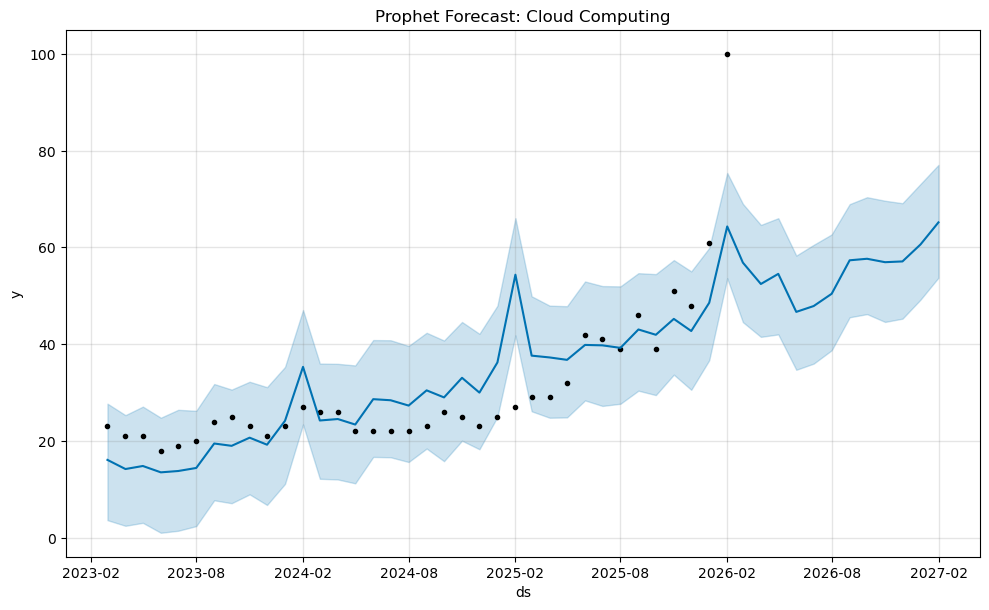

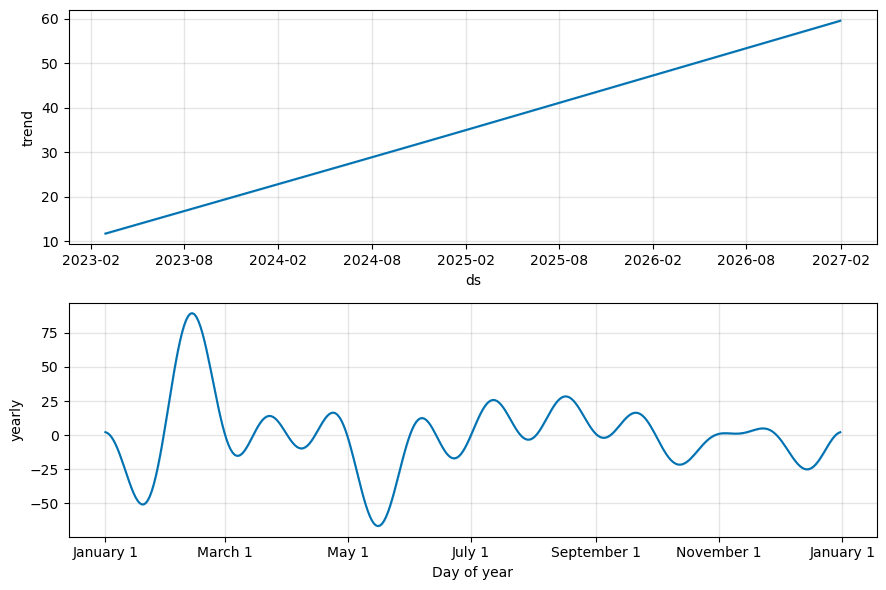

In [39]:
from prophet import Prophet

model = Prophet()
model.fit(ts)

future = model.make_future_dataframe(periods=12, freq="M")  # 预测未来12个月
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title(f"Prophet Forecast: {skill_name}")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [41]:
skills = ["Python","Generative AI","Machine Learning","Cloud Computing"]

from prophet import Prophet

for skill in skills:

    ts = trends[[skill]].reset_index()
    ts.columns = ["ds","y"]

    model = Prophet()
    model.fit(ts)

    future = model.make_future_dataframe(periods=12,freq="M")
    forecast = model.predict(future)

    forecast_out = forecast[["ds","yhat","yhat_lower","yhat_upper"]]

    print(skill)
    display(forecast_out.head())

    forecast_out.to_csv(f"forecast_{skill.replace(' ','_')}.csv",index=False)

    print("saved\n")

16:03:32 - cmdstanpy - INFO - Chain [1] start processing
16:03:33 - cmdstanpy - INFO - Chain [1] done processing


Python


C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
0,2023-03-01,98.433309,95.262430,101.600329
1,2023-04-01,93.542177,90.520143,96.626705
2,2023-05-01,85.460489,82.383805,88.324074
3,2023-06-01,85.090107,81.985169,88.308823
4,2023-07-01,84.462095,81.205400,87.572286


16:03:33 - cmdstanpy - INFO - Chain [1] start processing


...

16:03:34 - cmdstanpy - INFO - Chain [1] done processing


Cloud Computing


C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
0,2023-03-01,16.094201,4.422942,29.333961
1,2023-04-01,14.205211,2.247174,26.608178
2,2023-05-01,14.831998,1.865540,26.341011
3,2023-06-01,13.519635,2.201689,26.191786
4,2023-07-01,13.796651,1.423838,26.149801


saved



In [43]:
from prophet import Prophet

all_forecasts = []

for skill in trends.columns:
    ts = trends[[skill]].reset_index()
    ts.columns = ["ds","y"]

    m = Prophet()
    m.fit(ts)

    future = m.make_future_dataframe(periods=12, freq="M")
    fc = m.predict(future)[["ds","yhat","yhat_lower","yhat_upper"]]
    fc["skill"] = skill

    all_forecasts.append(fc)

all_forecasts_df = pd.concat(all_forecasts, ignore_index=True)
all_forecasts_df.to_csv("all_skills_prophet_forecasts.csv", index=False)

all_forecasts_df

16:03:37 - cmdstanpy - INFO - Chain [1] start processing
16:03:37 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
16:03:38 - cmdstanpy - INFO - Chain [1] start processing
16:03:38 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
16:03:38 - cmdstanpy - INFO - Chain [1] start processing
16:03:38 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Liliu\anaconda3\envs\appliedML\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(
16:03:38 - cmdstanpy - INFO - C

,ds,yhat,yhat_lower,yhat_upper,skill
0,2023-03-01,20.041201,4.558562,34.024024,Big Data
1,2023-04-01,18.184825,2.821288,31.923689,Big Data
2,2023-05-01,16.742528,1.905855,31.627959,Big Data
3,2023-06-01,15.493597,0.751810,29.413824,Big Data
4,2023-07-01,20.867094,7.376090,35.032303,Big Data
...,...,...,...,...,...
1003,2026-09-30,57.486584,52.562037,62.389737,TensorFlow
1004,2026-10-31,56.573068,51.164263,61.540495,TensorFlow
1005,2026-11-30,43.764358,38.410305,48.368922,TensorFlow
1006,2026-12-31,45.609457,40.349581,50.704536,TensorFlow
